# Predicting F1 race standings based on previous races and free practice sessions
The goal of this would be to predict both qualifying and race standings

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import concurrent.futures

import fastf1
import logging

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())
print('fastf1:', fastf1.__version__)

fastf1.Cache.enable_cache('../data/formula-1')

torch: 2.11.0+cpu | cuda: False
fastf1: 3.8.3


# Model 1: Naive version
Inputs:
- Free practice GP data

Output:
- Q1 Qualifying best lap time

Q1 only exists since 2006

In [ ]:
import time
import threading

logging.getLogger("fastf1").setLevel(logging.CRITICAL)

# Global rate limiter — enforces minimum gap between ALL session.load() calls
# across all threads combined. 400/hr = 9s per load (safety margin under 500/hr limit).
class RateLimiter:
    def __init__(self, calls_per_hour):
        self._interval = 3600 / calls_per_hour
        self._lock = threading.Lock()
        self._last = 0.0

    def wait(self):
        with self._lock:
            gap = self._interval - (time.monotonic() - self._last)
            if gap > 0:
                time.sleep(gap)
            self._last = time.monotonic()

_limiter = RateLimiter(calls_per_hour=400)

def best_laps(session):
    return (
        session.laps
        .pick_quicklaps()
        .groupby('Driver')['LapTime']
        .min()
        .dt.total_seconds()
    )

def load_event(year, round_num, event_name):
    sessions = {}
    for name, label in [('FP1', 'fp1'), ('FP2', 'fp2'), ('FP3', 'fp3'), ('Q', 'q')]:
        try:
            s = fastf1.get_session(year, round_num, name)
            _limiter.wait()
            s.load(telemetry=False, weather=False, messages=False)
            sessions[label] = best_laps(s)
        except Exception:
            return None  # sprint weekend or missing session

    merged = pd.concat(sessions.values(), axis=1, keys=sessions.keys()).dropna()
    merged.columns = ['FP1', 'FP2', 'FP3', 'Qualifying']
    merged['year'] = year
    merged['event'] = event_name
    merged['driver'] = merged.index
    return (year, event_name, merged)

events = []
for year in range(2018, 2026):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    for _, event in schedule.iterrows():
        events.append((year, int(event['RoundNumber']), event['EventName']))

# 3 workers: one loads while others process or wait on the rate limiter
rows = []
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as pool:
    futures = {pool.submit(load_event, y, r, n): (y, n) for y, r, n in events}
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is not None:
            year, event_name, merged = result
            rows.append(merged)
            print(f'{year} {event_name}: {len(merged)} drivers')

# After this cell completes, all data is cached — subsequent runs skip the API entirely
fastf1.Cache.offline_mode(True)

all_data = pd.concat(rows, ignore_index=True)
print(f'\nTotal rows: {len(all_data)}')
all_data.head()

In [9]:
all_data.groupby('event').size()

event
Australian Grand Prix        18
Austrian Grand Prix          18
Azerbaijan Grand Prix        20
Bahrain Grand Prix           14
British Grand Prix           18
Canadian Grand Prix          18
Dutch Grand Prix             18
Emilia Romagna Grand Prix    19
Hungarian Grand Prix         18
Italian Grand Prix           18
Japanese Grand Prix          19
Mexico City Grand Prix       11
Monaco Grand Prix            20
Saudi Arabian Grand Prix     19
Singapore Grand Prix         19
Spanish Grand Prix           18
dtype: int64

In [4]:
X_numpy = all_data[['FP1', 'FP2', 'FP3']].values
y_numpy = all_data['Qualifying'].values

print(f'X: {X_numpy.shape}, y: {y_numpy.shape}')

X: (285, 3), y: (285,)


In [5]:
class NaiveQualiNetwork(nn.Module):
    def __init__(self, in_features, num_classes) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,num_classes)
        )

    def forward(self, x):
        return self.layers(x).squeeze(1)

In [6]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # type: ignore
print(f"Using {device} device")

model = NaiveQualiNetwork(in_features=3, num_classes=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

Using cpu device


In [12]:
X = torch.tensor(X_numpy, dtype=torch.float32)
y = torch.tensor(y_numpy, dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [13]:
num_epochs = 1000
loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    loss_history.append(epoch_loss / len(dataloader))
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{num_epochs}  loss={loss_history[-1]:.4f}')

Epoch  100/1000  loss=0.2860
Epoch  200/1000  loss=0.2931
Epoch  300/1000  loss=0.2941
Epoch  400/1000  loss=0.3106
Epoch  500/1000  loss=0.2778
Epoch  600/1000  loss=0.3201
Epoch  700/1000  loss=0.3219
Epoch  800/1000  loss=0.2906
Epoch  900/1000  loss=0.2958
Epoch 1000/1000  loss=0.3592


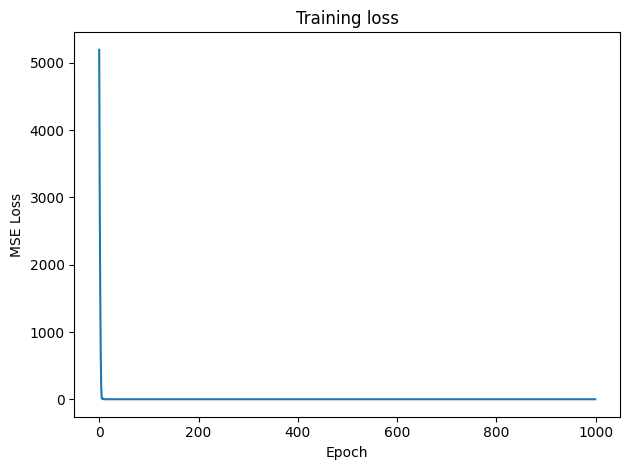

In [11]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training loss')
plt.tight_layout()
plt.show()

In [14]:
model.eval()
with torch.no_grad():
    predicted = model(X.to(device)).cpu().numpy()

results = all_data[['year', 'event', 'driver', 'Qualifying']].copy()
results['Predicted'] = predicted
results['Error (s)'] = (results['Predicted'] - results['Qualifying']).round(3)
results.sort_values('Error (s)').head(20)

,year,event,driver,Qualifying,Predicted,Error (s)
235,2025,Azerbaijan Grand Prix,ALB,103.778,100.732315,-3.046
238,2025,Azerbaijan Grand Prix,BEA,102.666,100.798187,-1.868
248,2025,Azerbaijan Grand Prix,OCO,103.004,101.266502,-1.737
244,2025,Azerbaijan Grand Prix,HUL,102.916,101.239449,-1.677
79,2025,Emilia Romagna Grand Prix,HUL,76.518,75.079811,-1.438
243,2025,Azerbaijan Grand Prix,HAM,101.821,100.400467,-1.421
80,2025,Emilia Romagna Grand Prix,LAW,76.379,75.020027,-1.359
172,2025,British Grand Prix,LAW,86.440,85.134903,-1.305
74,2025,Emilia Romagna Grand Prix,BOR,76.260,74.967400,-1.293
83,2025,Emilia Romagna Grand Prix,OCO,76.613,75.322525,-1.290
